In [4]:
from google.colab import files
uploaded = files.upload()
print("تم رفع:", list(uploaded.keys()))

Saving laila_features_all_prompts.csv to laila_features_all_prompts.csv
تم رفع: ['laila_features_all_prompts.csv']


In [7]:
!pip install -q xgboost lightgbm catboost shap

In [1]:
!pip install -q xgboost lightgbm catboost shap optuna
print("تم تثبيت المكتبات")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 38.4 MB/s eta 0:00:00
تم تثبيت المكتبات


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# تحميل الملفك
import glob
csv_file = [f for f in glob.glob('*.csv') if 'all_prompts' in f.lower()][0]
df = pd.read_csv(csv_file)

print(f"أبعاد البيانات: {df.shape[0]} مقالة × {df.shape[1]} عمود")
print(f"\nتوزيع المقالات على المواضيع:")
print(df['prompt_id'].value_counts().sort_index())

# تعريف الأعمدة
META_COLS = ['essay_id', 'prompt_id', 'essay', 'prompt', 'prompt_type', 'prompt_type_encoded']
SCORE_COLS = ['relevance', 'organization', 'vocabulary', 'style', 'development',
'mechanics', 'grammar', 'holistic']
FEATURE_COLS = [c for c in df.columns
if c not in META_COLS and c not in SCORE_COLS
and df[c].dtype in [np.int64, np.float64]]

print(f"\nعدد الفيتشرز: {len(FEATURE_COLS)}")
print(f"عدد الدرجات: {len(SCORE_COLS)}")

أبعاد البيانات: 7859 مقالة × 429 عمود

توزيع المقالات على المواضيع:
prompt_id
1    1122
2    1168
3     521
4     500
5    1181
6    1162
7    1143
8    1062
Name: count, dtype: int64

عدد الفيتشرز: 414
عدد الدرجات: 8


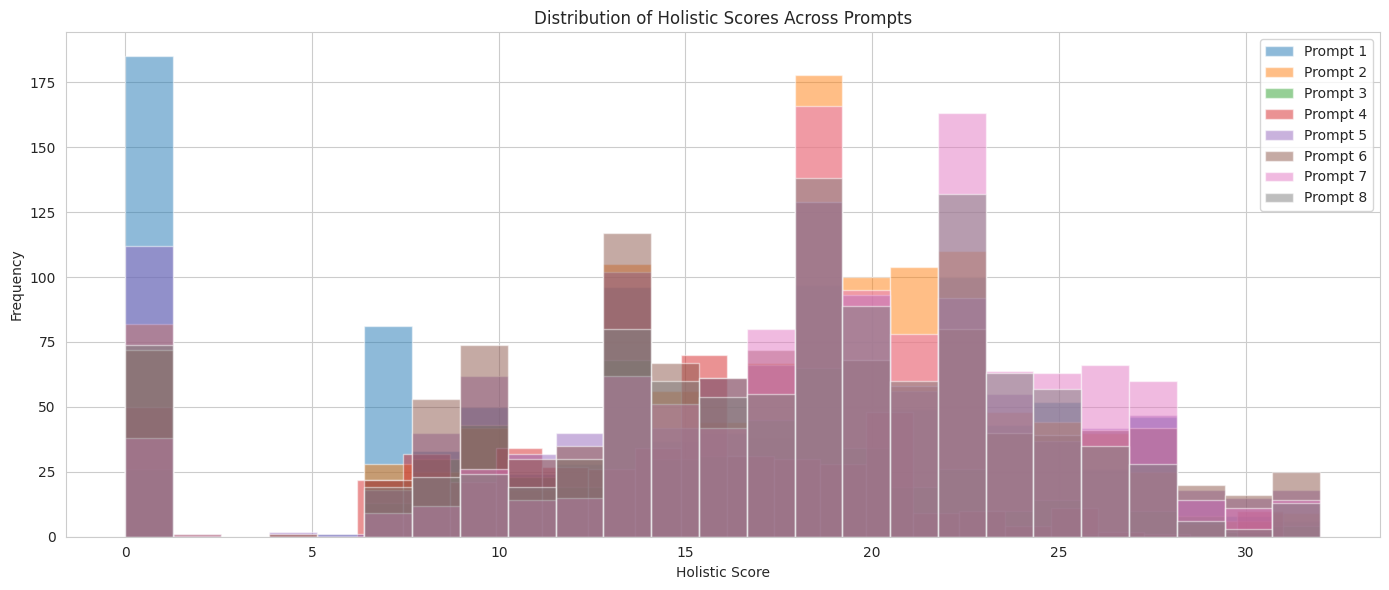


متوسط الدرجات لكل موضوع:
           relevance  organization  vocabulary  style  development  mechanics  \
prompt_id                                                                       
1               1.52          2.29        2.11   2.37         2.33       2.10   
2               1.80          2.59        2.52   2.73         2.58       2.44   
3               1.86          2.35        1.92   2.48         2.41       2.24   
4               1.72          2.13        1.70   2.22         2.16       2.04   
5               1.75          2.52        2.47   2.59         2.54       2.44   
6               1.84          2.64        2.50   2.62         2.69       2.26   
7               1.92          3.10        2.72   3.17         3.09       2.79   
8               1.83          2.81        2.47   2.78         2.64       2.59   

           grammar  holistic  
prompt_id                     
1             2.08     14.81  
2             2.46     17.13  
3             2.14     15.40  
4       

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
for prompt in sorted(df['prompt_id'].unique()):
    subset = df[df['prompt_id'] == prompt]['holistic']
    ax.hist(subset, bins=25, alpha=0.5, label=f'Prompt {prompt}')
ax.set_xlabel('Holistic Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Holistic Scores Across Prompts')
ax.legend()
plt.tight_layout()
plt.savefig('scores_by_prompt.png', bbox_inches='tight')
plt.show()

print("\nمتوسط الدرجات لكل موضوع:")
print(df.groupby('prompt_id')[SCORE_COLS].mean().round(2))

In [9]:
def handle_outliers(df, cols, lower=0.01, upper=0.99):
    df_clean = df.copy()
    outliers_count = 0
    for col in cols:
        q_low = df_clean[col].quantile(lower)
        q_high = df_clean[col].quantile(upper)
        n_outliers = ((df_clean[col] < q_low) | (df_clean[col] > q_high)).sum()
        outliers_count += n_outliers
        df_clean[col] = df_clean[col].clip(q_low, q_high)
    return df_clean, outliers_count

df_processed, n_outliers = handle_outliers(df, FEATURE_COLS)
print(f"تم معالجة {n_outliers} قيمة متطرفة")

تم معالجة 26592 قيمة متطرفة


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

X = df_processed[FEATURE_COLS].values
y_dict = {score: df_processed[score].values for score in SCORE_COLS}

print(f"X shape: {X.shape}")
for score in SCORE_COLS:
    print(f"  y_{score}: min={y_dict[score].min()}, max={y_dict[score].max()}, mean={y_dict[score].mean():.2f}")

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
print(f"\nاستخدام {N_FOLDS}-Fold Cross-Validation")

X shape: (7859, 414)
  y_relevance: min=0, max=2, mean=1.78
  y_organization: min=0, max=5, mean=2.60
  y_vocabulary: min=0, max=5, mean=2.38
  y_style: min=0, max=5, mean=2.66
  y_development: min=0, max=5, mean=2.60
  y_mechanics: min=0, max=5, mean=2.40
  y_grammar: min=0, max=5, mean=2.36
  y_holistic: min=0, max=32, mean=16.78

استخدام 5-Fold Cross-Validation


In [11]:
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold

# 1. حذف الفيتشرز ذات التباين المنخفض
selector_var = VarianceThreshold(threshold=0.01)
X_var_filtered = selector_var.fit_transform(X)
kept_features_var = [FEATURE_COLS[i] for i, keep in enumerate(selector_var.get_support()) if keep]
print(f"بعد حذف الفيتشرز ذات التباين المنخفض: {X_var_filtered.shape[1]} (من {len(FEATURE_COLS)})")

# 2. اختيار أفضل K فيتشر بناءً على الارتباط بالدرجة الكلية
K_BEST = 200 # نختار أفضل 200 فيتشر
selector_k = SelectKBest(score_func=f_regression, k=min(K_BEST, X_var_filtered.shape[1]))
X_selected = selector_k.fit_transform(X_var_filtered, y_dict['holistic'])
kept_indices = selector_k.get_support(indices=True)
SELECTED_FEATURES = [kept_features_var[i] for i in kept_indices]

print(f"الفيتشرز النهائية المختارة: {len(SELECTED_FEATURES)}")

# حفظ نسخة كاملة ونسخة مختارة
X_full = X.copy()
X_sel = X_selected.copy()

print(f"\nX_full shape: {X_full.shape}")
print(f"X_sel shape: {X_sel.shape}")

بعد حذف الفيتشرز ذات التباين المنخفض: 371 (من 414)
الفيتشرز النهائية المختارة: 200

X_full shape: (7859, 414)
X_sel shape: (7859, 200)


In [13]:
from sklearn.metrics import cohen_kappa_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

def quadratic_weighted_kappa(y_true, y_pred):
    y_true_int = np.round(y_true).astype(int)
    y_pred_int = np.round(np.clip(y_pred, y_true.min(), y_true.max())).astype(int)
    return cohen_kappa_score(y_true_int, y_pred_int, weights='quadratic')

def evaluate_predictions(y_true, y_pred):
    return {
        'QWK': quadratic_weighted_kappa(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'Pearson': pearsonr(y_true, y_pred)[0],
        'Spearman': spearmanr(y_true, y_pred)[0]
    }

print("تم تعريف دوال التقييم")

تم تعريف دوال التقييم


In [15]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from tqdm.notebook import tqdm

def get_models():
    return {
        'Ridge': (lambda: Ridge(alpha=1.0, random_state=42), True),
        'RandomForest': (lambda: RandomForestRegressor(
            n_estimators=300, max_depth=15, min_samples_split=5,
            random_state=42, n_jobs=-1), False),
        'XGBoost': (lambda: XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbosity=0), False),
        'LightGBM': (lambda: LGBMRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbosity=-1), False),
        'CatBoost': (lambda: CatBoostRegressor(
            iterations=500, depth=6, learning_rate=0.05,
            random_state=42, verbose=0), False),
    }

def train_cv(X_data, y, kf, models_config):
    results = {}
    oof_preds = {}
    for model_name, (factory, needs_scaling) in models_config.items():
        fold_metrics = []
        oof = np.zeros_like(y, dtype=float)
        for train_idx, val_idx in kf.split(X_data):
            X_tr, X_vl = X_data[train_idx], X_data[val_idx]
            y_tr, y_vl = y[train_idx], y[val_idx]
            if needs_scaling:
                sc = StandardScaler()
                X_tr = sc.fit_transform(X_tr)
                X_vl = sc.transform(X_vl)
            m = factory()
            m.fit(X_tr, y_tr)
            pred = m.predict(X_vl)
            oof[val_idx] = pred
            fold_metrics.append(evaluate_predictions(y_vl, pred))
        avg = {k: np.mean([fm[k] for fm in fold_metrics]) for k in fold_metrics[0].keys()}
        avg['QWK_std'] = np.std([fm['QWK'] for fm in fold_metrics])
        results[model_name] = avg
        oof_preds[model_name] = oof
    return results, oof_preds

print("تم تعريف دوال التدريب")

تم تعريف دوال التدريب


In [17]:
print("بدء التدريب... قد يستغرق وقتاً طويلاً\n")

all_results = {}
all_oof = {}
models_config = get_models()

for score in tqdm(SCORE_COLS, desc='Training'):
    y = y_dict[score]
    results, oof = train_cv(X_sel, y, kf, models_config)
    all_results[score] = results
    all_oof[score] = oof

print("\nانتهى التدريب!")

results_rows = []
for score in SCORE_COLS:
    for model_name in models_config.keys():
        r = all_results[score][model_name]
        results_rows.append({
            'Score': score,
            'Model': model_name,
            'QWK': r['QWK'],
            'QWK_std': r['QWK_std'],
            'RMSE': r['RMSE'],
            'MAE': r['MAE'],
            'Pearson': r['Pearson']
        })

results_df = pd.DataFrame(results_rows).round(4)
print("\nنتائج كل النماذج:\n")
print(results_df.to_string(index=False))
results_df.to_csv('all_models_results.csv', index=False)

بدء التدريب... قد يستغرق وقتاً طويلاً



Training:   0%|          | 0/8 [00:00<?, ?it/s]


انتهى التدريب!

نتائج كل النماذج:

       Score        Model    QWK  QWK_std   RMSE    MAE  Pearson
   relevance        Ridge 0.3500   0.0338 0.5121 0.3180   0.4652
   relevance RandomForest 0.4216   0.0363 0.4935 0.2866   0.5197
   relevance      XGBoost 0.4459   0.0378 0.4942 0.2857   0.5218
   relevance     LightGBM 0.4352   0.0437 0.4936 0.2852   0.5230
   relevance     CatBoost 0.4211   0.0348 0.4897 0.2809   0.5297
organization        Ridge 0.6801   0.0193 0.8796 0.6384   0.7297
organization RandomForest 0.6940   0.0202 0.8546 0.6076   0.7472
organization      XGBoost 0.7002   0.0226 0.8563 0.6144   0.7463
organization     LightGBM 0.7020   0.0148 0.8581 0.6152   0.7452
organization     CatBoost 0.6973   0.0148 0.8480 0.6069   0.7516
  vocabulary        Ridge 0.6798   0.0151 0.8442 0.6111   0.7323
  vocabulary RandomForest 0.7055   0.0157 0.8131 0.5771   0.7546
  vocabulary      XGBoost 0.7098   0.0196 0.8109 0.5806   0.7562
  vocabulary     LightGBM 0.7042   0.0140 0.8139 0.582

In [18]:
ensemble_results = {}

for score in SCORE_COLS:
    y = y_dict[score]
    model_qwks = {m: all_results[score][m]['QWK'] for m in models_config.keys()}
    sorted_models = sorted(model_qwks.items(), key=lambda x: -x[1])
    top_3 = [m[0] for m in sorted_models[:3]]
    weights = np.array([model_qwks[m] for m in top_3])
    weights = weights / weights.sum()
    ensemble_pred = np.zeros_like(y, dtype=float)
    for m, w in zip(top_3, weights):
        ensemble_pred += w * all_oof[score][m]
    metrics = evaluate_predictions(y, ensemble_pred)
    ensemble_results[score] = {
        'top_models': top_3,
        'weights': weights.tolist(),
        **metrics
    }

print("مقارنة: أفضل نموذج فردي vs Ensemble\n")
comparison = []
for score in SCORE_COLS:
    best_single = max(models_config.keys(), key=lambda m: all_results[score][m]['QWK'])
    best_qwk = all_results[score][best_single]['QWK']
    ens_qwk = ensemble_results[score]['QWK']
    comparison.append({
        'Score': score,
        'Best Single': best_single,
        'Best QWK': round(best_qwk, 4),
        'Ensemble QWK': round(ens_qwk, 4),
        'Improvement': round(ens_qwk - best_qwk, 4)
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))
comparison_df.to_csv('ensemble_comparison.csv', index=False)

مقارنة: أفضل نموذج فردي vs Ensemble

       Score Best Single  Best QWK  Ensemble QWK  Improvement
   relevance     XGBoost    0.4459        0.4474       0.0014
organization    LightGBM    0.7020        0.7064       0.0044
  vocabulary     XGBoost    0.7098        0.7112       0.0014
       style     XGBoost    0.6937        0.6947       0.0010
 development     XGBoost    0.6410        0.6394      -0.0016
   mechanics    LightGBM    0.6329        0.6316      -0.0013
     grammar    CatBoost    0.6676        0.6697       0.0021
    holistic    LightGBM    0.7276        0.7298       0.0022


In [19]:
prompt_ids = sorted(df_processed['prompt_id'].unique())
cross_prompt_results = {}

print(f"Cross-Prompt Evaluation على {len(prompt_ids)} مواضيع\n")

for score in tqdm(SCORE_COLS, desc='Cross-Prompt'):
    cross_prompt_results[score] = {}
    for test_prompt in prompt_ids:
        train_mask = df_processed['prompt_id'] != test_prompt
        test_mask = df_processed['prompt_id'] == test_prompt
        X_train = df_processed.loc[train_mask, SELECTED_FEATURES].values
        X_test = df_processed.loc[test_mask, SELECTED_FEATURES].values
        y_train = df_processed.loc[train_mask, score].values
        y_test = df_processed.loc[test_mask, score].values
        model = XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbosity=0
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        cross_prompt_results[score][test_prompt] = evaluate_predictions(y_test, pred)

cross_qwk_df = pd.DataFrame({
    score: {f'Prompt {p}': cross_prompt_results[score][p]['QWK'] for p in prompt_ids}
    for score in SCORE_COLS
})
cross_qwk_df.loc['Mean'] = cross_qwk_df.mean()
cross_qwk_df.loc['Std'] = cross_qwk_df.iloc[:-1].std()
cross_qwk_df = cross_qwk_df.round(4)

print("\nCross-Prompt QWK:\n")
print(cross_qwk_df.to_string())
cross_qwk_df.to_csv('cross_prompt_qwk.csv')

print("\nمقارنة التعميم: In-Prompt vs Cross-Prompt\n")
gen_comp = pd.DataFrame({
    'In-Prompt QWK': [all_results[s]['XGBoost']['QWK'] for s in SCORE_COLS],
    'Cross-Prompt QWK (Mean)': [cross_qwk_df.loc['Mean', s] for s in SCORE_COLS],
}, index=SCORE_COLS)
gen_comp['Gap'] = gen_comp['In-Prompt QWK'] - gen_comp['Cross-Prompt QWK (Mean)']
gen_comp = gen_comp.round(4)
print(gen_comp.to_string())
gen_comp.to_csv('generalization_comparison.csv')

Cross-Prompt Evaluation على 8 مواضيع



Cross-Prompt:   0%|          | 0/8 [00:00<?, ?it/s]


Cross-Prompt QWK:

          relevance  organization  vocabulary   style  development  mechanics  grammar  holistic
Prompt 1     0.1981        0.4892      0.5082  0.4863       0.4398     0.3961   0.4579    0.4744
Prompt 2     0.4088        0.7113      0.7309  0.7436       0.6678     0.6474   0.7044    0.7678
Prompt 3     0.3510        0.7468      0.6698  0.6973       0.5975     0.6400   0.6756    0.7552
Prompt 4     0.4387        0.6883      0.6475  0.7096       0.6340     0.6607   0.6616    0.7084
Prompt 5     0.3103        0.6000      0.5269  0.5551       0.5265     0.4231   0.4581    0.5562
Prompt 6     0.4605        0.6931      0.6471  0.6833       0.6053     0.6499   0.6786    0.7344
Prompt 7     0.4109        0.6912      0.7291  0.6708       0.5654     0.6043   0.6430    0.7247
Prompt 8     0.4411        0.6764      0.7237  0.6747       0.5866     0.6279   0.6407    0.7214
Mean         0.3774        0.6621      0.6479  0.6526       0.5779     0.5812   0.6150    0.6803
Std       

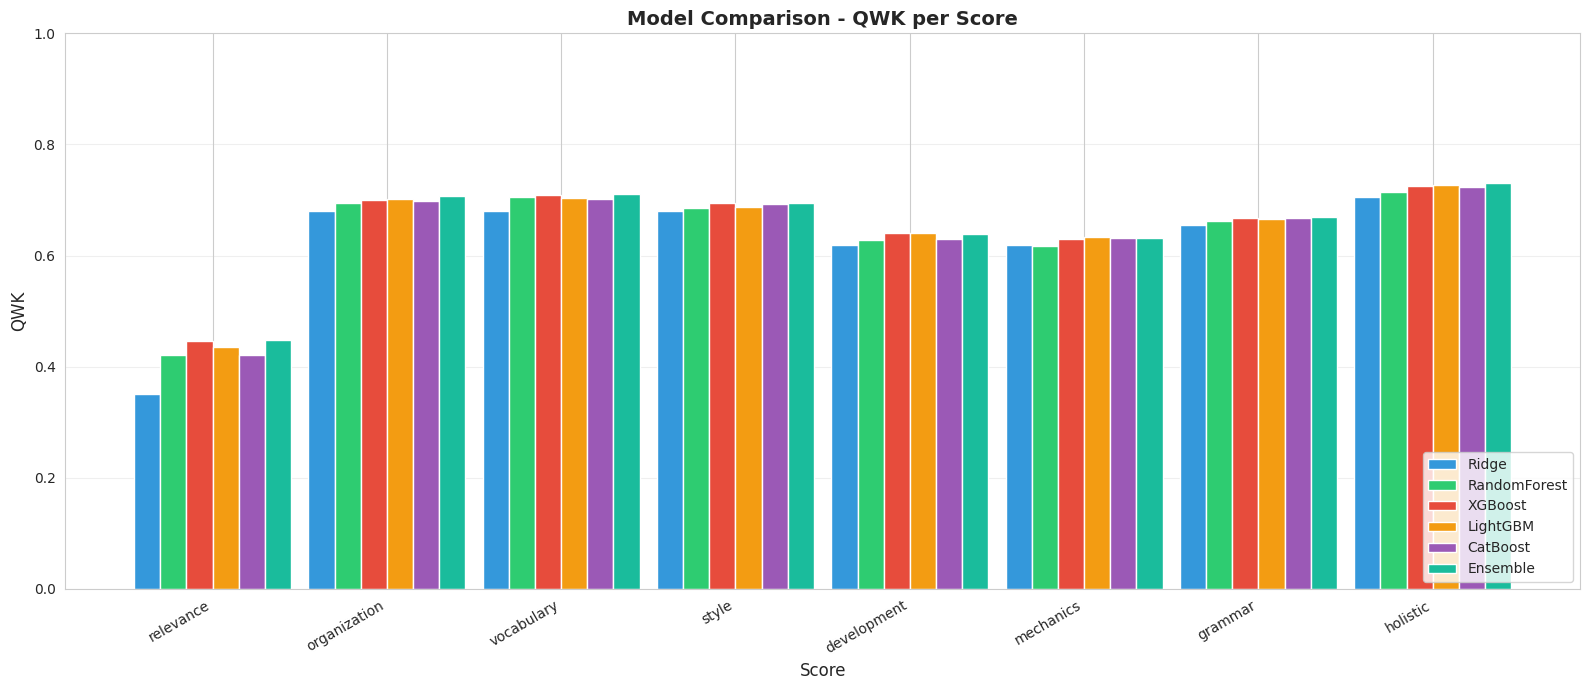

In [20]:
fig, ax = plt.subplots(figsize=(16, 7))

model_names = list(models_config.keys()) + ['Ensemble']
x = np.arange(len(SCORE_COLS))
width = 0.15

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

for i, m in enumerate(model_names):
    if m == 'Ensemble':
        qwks = [ensemble_results[s]['QWK'] for s in SCORE_COLS]
    else:
        qwks = [all_results[s][m]['QWK'] for s in SCORE_COLS]
    ax.bar(x + i*width - 2.5*width, qwks, width, label=m, color=colors[i])

ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('QWK', fontsize=12)
ax.set_title('Model Comparison - QWK per Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(SCORE_COLS, rotation=30, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('model_comparison_all.png', bbox_inches='tight')
plt.show()

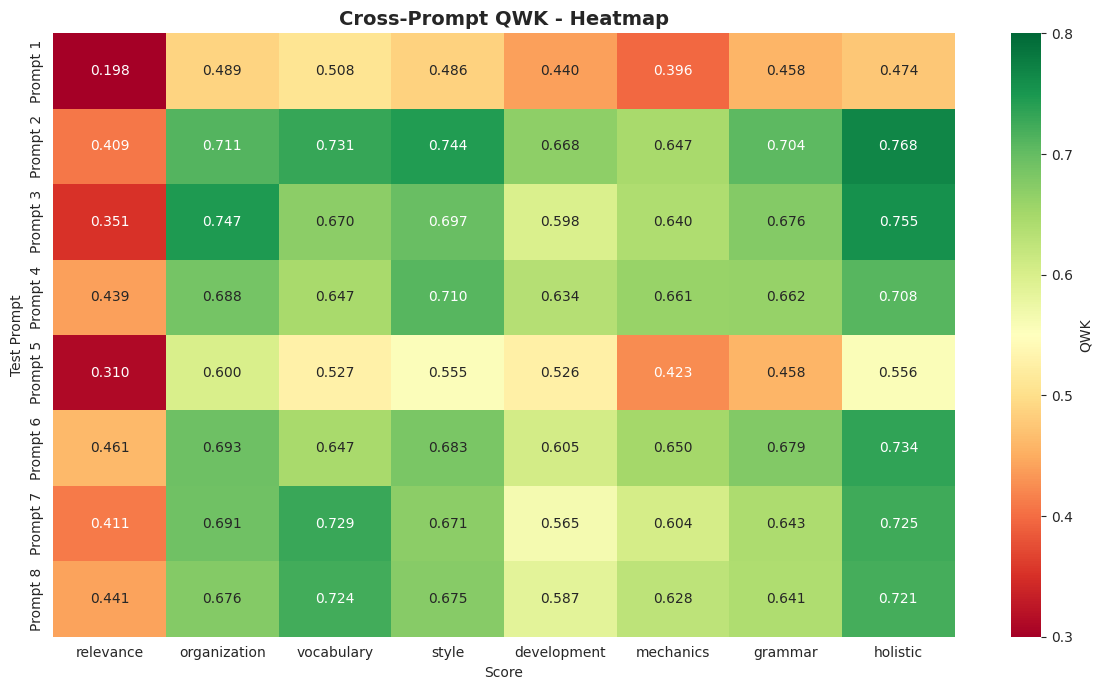

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))
heat_data = cross_qwk_df.iloc[:-2]
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.3, vmax=0.8, ax=ax, cbar_kws={'label': 'QWK'})
ax.set_title('Cross-Prompt QWK - Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Test Prompt')
plt.tight_layout()
plt.savefig('cross_prompt_heatmap.png', bbox_inches='tight')
plt.show()

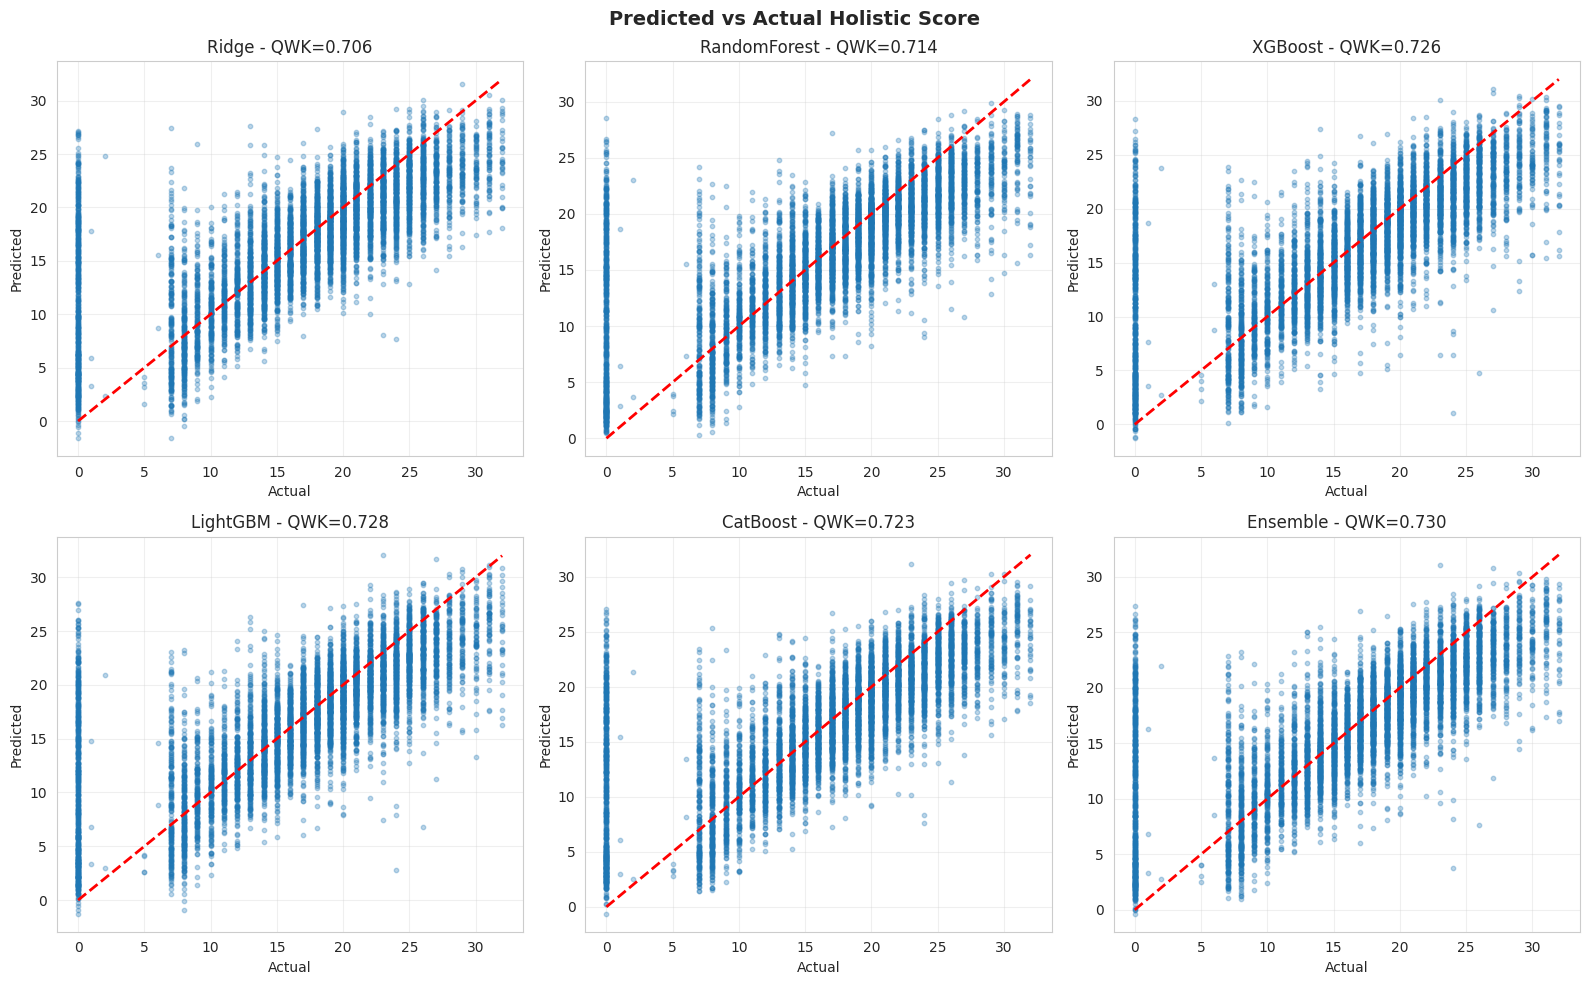

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, m in enumerate(list(models_config.keys()) + ['Ensemble']):
    ax = axes[i]
    if m == 'Ensemble':
        y_pred = np.zeros_like(y_dict['holistic'], dtype=float)
        top_3 = ensemble_results['holistic']['top_models']
        weights = ensemble_results['holistic']['weights']
        for mdl, w in zip(top_3, weights):
            y_pred += w * all_oof['holistic'][mdl]
    else:
        y_pred = all_oof['holistic'][m]
    y_true = y_dict['holistic']
    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    qwk = quadratic_weighted_kappa(y_true, y_pred)
    ax.set_title(f'{m} - QWK={qwk:.3f}')
    ax.grid(alpha=0.3)

plt.suptitle('Predicted vs Actual Holistic Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', bbox_inches='tight')
plt.show()

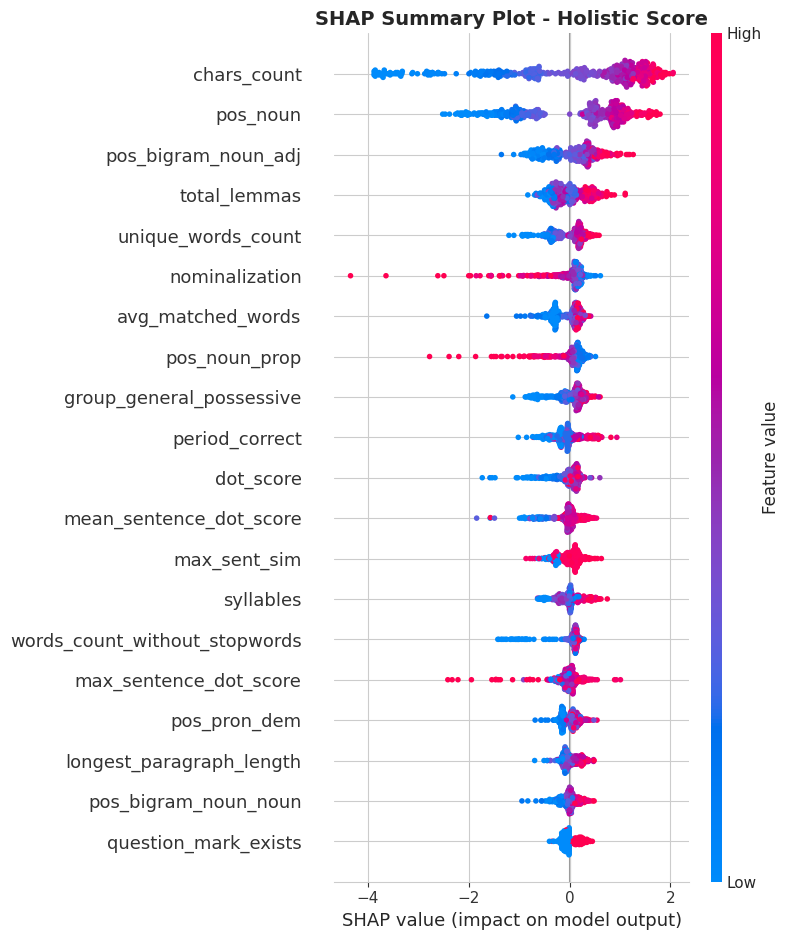


أهم 20 فيتشر حسب SHAP:
                      feature  mean_abs_shap
                  chars_count       1.311514
                     pos_noun       0.972843
          pos_bigram_noun_adj       0.412808
                 total_lemmas       0.288373
           unique_words_count       0.267972
               nominalization       0.254106
            avg_matched_words       0.223343
                pos_noun_prop       0.222083
     group_general_possessive       0.216369
               period_correct       0.213562
                    dot_score       0.182117
      mean_sentence_dot_score       0.180850
                 max_sent_sim       0.177370
                    syllables       0.172772
words_count_without_stopwords       0.170131
       max_sentence_dot_score       0.153548
                 pos_pron_dem       0.129680
     longest_paragraph_length       0.129668
         pos_bigram_noun_noun       0.119976
         question_mark_exists       0.115908


In [23]:
import shap

model_shap = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, n_jobs=-1, verbosity=0
)
model_shap.fit(X_sel, y_dict['holistic'])

sample_size = min(500, len(X_sel))
sample_idx = np.random.RandomState(42).choice(len(X_sel), sample_size, replace=False)
X_sample = X_sel[sample_idx]

explainer = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_sample, feature_names=SELECTED_FEATURES,
                  max_display=20, show=False)
plt.title('SHAP Summary Plot - Holistic Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=100)
plt.show()

mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': SELECTED_FEATURES,
    'mean_abs_shap': mean_shap
}).sort_values('mean_abs_shap', ascending=False)

print("\nأهم 20 فيتشر حسب SHAP:")
print(shap_importance.head(20).to_string(index=False))
shap_importance.to_csv('shap_importance.csv', index=False)

متوسط الخطأ حسب الموضوع:
            count  mean   std   min   25%   50%   75%    max
prompt_id                                                   
1          1122.0  5.06  4.76  0.00  1.77  3.66  6.50  25.89
2          1168.0  2.75  2.99  0.00  0.91  1.97  3.55  26.51
3           521.0  2.54  2.92  0.00  0.86  1.78  3.20  23.29
4           500.0  3.01  3.82  0.01  0.96  1.96  3.43  28.29
5          1181.0  3.91  3.87  0.00  1.37  2.92  5.11  25.43
6          1162.0  3.16  3.30  0.00  1.09  2.43  4.19  25.59
7          1143.0  2.45  2.66  0.00  0.85  1.87  3.23  25.23
8          1062.0  2.85  3.54  0.00  0.85  1.85  3.44  27.19

متوسط الخطأ حسب طول المقالة:
length_bin
Very Short    3.02
Short         3.18
Medium        3.39
Long          4.25
Very Long     7.84
Name: error, dtype: float64


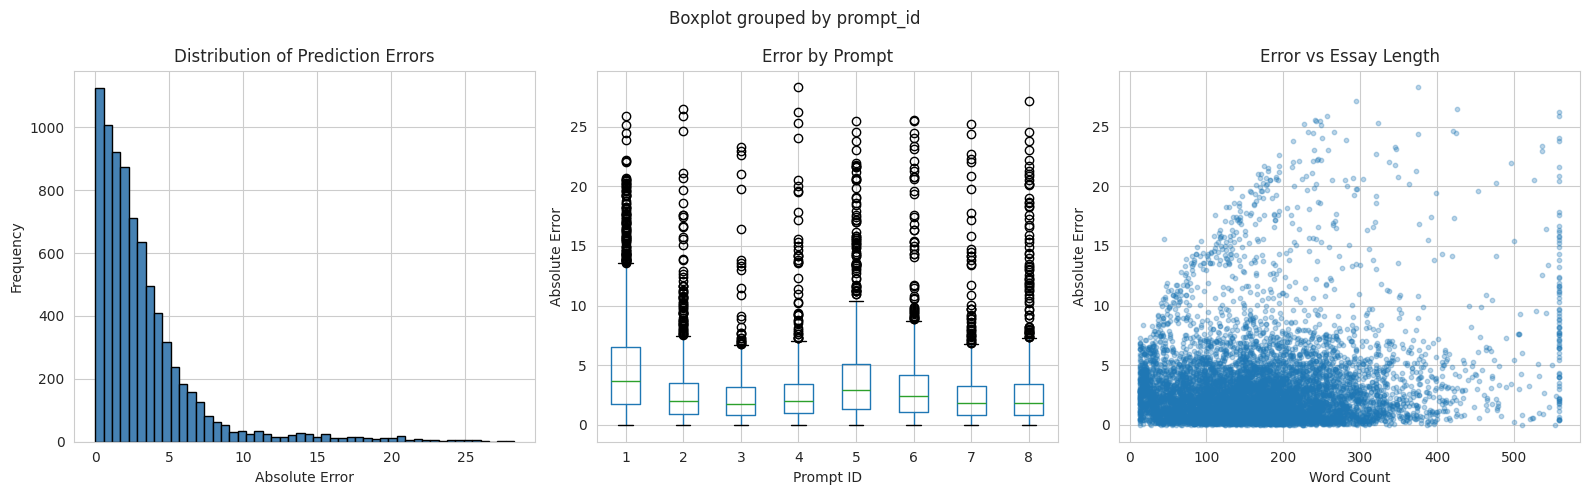

In [24]:
y_true = y_dict['holistic']
y_pred = all_oof['holistic']['XGBoost']
errors = np.abs(y_true - y_pred)

error_df = df_processed[['essay_id', 'prompt_id', 'holistic']].copy()
error_df['predicted'] = y_pred
error_df['error'] = errors
error_df['word_count'] = df_processed['words_count']

print("متوسط الخطأ حسب الموضوع:")
print(error_df.groupby('prompt_id')['error'].describe().round(2))

error_df['length_bin'] = pd.cut(error_df['word_count'], bins=5,
                                 labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])
print("\nمتوسط الخطأ حسب طول المقالة:")
print(error_df.groupby('length_bin')['error'].mean().round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(errors, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Absolute Error')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Prediction Errors')

error_df.boxplot(column='error', by='prompt_id', ax=axes[1])
axes[1].set_title('Error by Prompt')
axes[1].set_xlabel('Prompt ID')
axes[1].set_ylabel('Absolute Error')

axes[2].scatter(error_df['word_count'], errors, alpha=0.3, s=10)
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Absolute Error')
axes[2].set_title('Error vs Essay Length')

plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight')
plt.show()

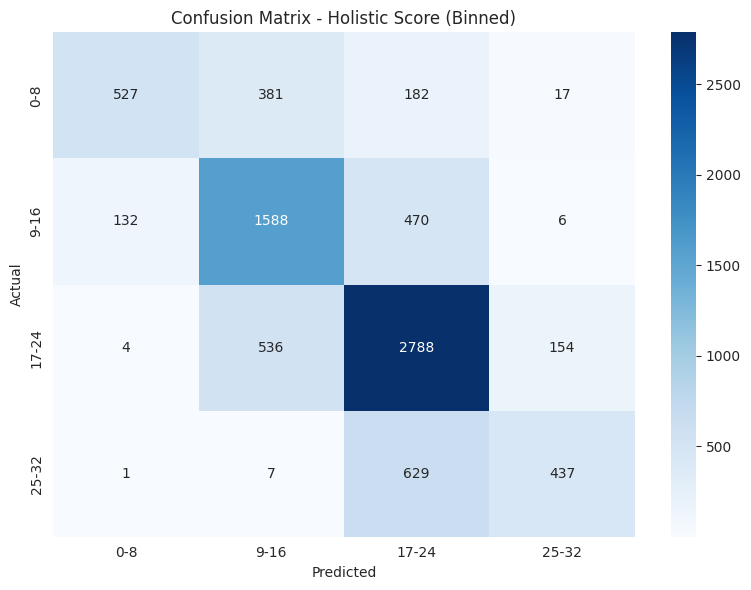

              precision    recall  f1-score   support

         0-8       0.79      0.48      0.60      1107
        9-16       0.63      0.72      0.67      2196
       17-24       0.69      0.80      0.74      3482
       25-32       0.71      0.41      0.52      1074

    accuracy                           0.68      7859
   macro avg       0.71      0.60      0.63      7859
weighted avg       0.69      0.68      0.67      7859



In [25]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_ens = np.zeros_like(y_dict['holistic'], dtype=float)
top_3 = ensemble_results['holistic']['top_models']
weights = ensemble_results['holistic']['weights']
for mdl, w in zip(top_3, weights):
    y_pred_ens += w * all_oof['holistic'][mdl]

bins = [-1, 8, 16, 24, 33]
labels = ['0-8', '9-16', '17-24', '25-32']
y_true_binned = pd.cut(y_dict['holistic'], bins=bins, labels=labels)
y_pred_binned = pd.cut(y_pred_ens, bins=bins, labels=labels)

cm = confusion_matrix(y_true_binned, y_pred_binned, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Holistic Score (Binned)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_true_binned, y_pred_binned, labels=labels, zero_division=0))

In [26]:
import zipfile
import os
from google.colab import files

output_files = [
    'all_models_results.csv',
    'ensemble_comparison.csv',
    'cross_prompt_qwk.csv',
    'generalization_comparison.csv',
    'shap_importance.csv',
    'scores_by_prompt.png',
    'model_comparison_all.png',
    'cross_prompt_heatmap.png',
    'predicted_vs_actual.png',
    'shap_summary.png',
    'error_analysis.png',
    'confusion_matrix.png',
]

zip_path = 'final_results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"أُضيف: {f}")

print(f"\nتم تجميع النتائج في: {zip_path}")
files.download(zip_path)

أُضيف: all_models_results.csv
أُضيف: ensemble_comparison.csv
أُضيف: cross_prompt_qwk.csv
أُضيف: generalization_comparison.csv
أُضيف: shap_importance.csv
أُضيف: scores_by_prompt.png
أُضيف: model_comparison_all.png
أُضيف: cross_prompt_heatmap.png
أُضيف: predicted_vs_actual.png
أُضيف: shap_summary.png
أُضيف: error_analysis.png
أُضيف: confusion_matrix.png

تم تجميع النتائج في: final_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
print("="*70)
print("الملخص النهائي لنتائج النظام")
print("="*70)

print(f"\nالبيانات:")
print(f"  عدد المقالات: {len(df_processed)}")
print(f"  عدد المواضيع: {len(prompt_ids)}")
print(f"  عدد الفيتشرز المختارة: {len(SELECTED_FEATURES)}")

print(f"\nأفضل نتائج QWK:")
for score in SCORE_COLS:
    best_single = max(models_config.keys(), key=lambda m: all_results[score][m]['QWK'])
    best_qwk = all_results[score][best_single]['QWK']
    ens_qwk = ensemble_results[score]['QWK']
    cross_qwk = cross_qwk_df.loc['Mean', score]
    winner = 'Ensemble' if ens_qwk > best_qwk else best_single
    winner_qwk = max(ens_qwk, best_qwk)
    print(f"  {score:15s} | Best: {winner} = {winner_qwk:.4f} | Cross-Prompt: {cross_qwk:.4f}")

avg_in_prompt = np.mean([max(all_results[s][m]['QWK'] for m in models_config.keys()) for s in SCORE_COLS])
avg_ensemble = np.mean([ensemble_results[s]['QWK'] for s in SCORE_COLS])
avg_cross = np.mean([cross_qwk_df.loc['Mean', s] for s in SCORE_COLS])

print(f"\nالمتوسطات:")
print(f"  In-Prompt (أفضل نموذج):  {avg_in_prompt:.4f}")
print(f"  Ensemble:                 {avg_ensemble:.4f}")
print(f"  Cross-Prompt:             {avg_cross:.4f}")
print(f"  Generalization Gap:       {avg_in_prompt - avg_cross:.4f}")

print("\n" + "="*70)

الملخص النهائي لنتائج النظام

البيانات:
  عدد المقالات: 7859
  عدد المواضيع: 8
  عدد الفيتشرز المختارة: 200

أفضل نتائج QWK:
  relevance       | Best: Ensemble = 0.4474 | Cross-Prompt: 0.3774
  organization    | Best: Ensemble = 0.7064 | Cross-Prompt: 0.6621
  vocabulary      | Best: Ensemble = 0.7112 | Cross-Prompt: 0.6479
  style           | Best: Ensemble = 0.6947 | Cross-Prompt: 0.6526
  development     | Best: XGBoost = 0.6410 | Cross-Prompt: 0.5779
  mechanics       | Best: LightGBM = 0.6329 | Cross-Prompt: 0.5812
  grammar         | Best: Ensemble = 0.6697 | Cross-Prompt: 0.6150
  holistic        | Best: Ensemble = 0.7298 | Cross-Prompt: 0.6803

المتوسطات:
  In-Prompt (أفضل نموذج):  0.6526
  Ensemble:                 0.6538
  Cross-Prompt:             0.5993
  Generalization Gap:       0.0533

